In [14]:
import os
from pathlib import Path

# Set project root automatically based on notebook location
PROJECT_ROOT = Path.cwd().parents[0]
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Project Root:", PROJECT_ROOT)
print("Raw Data Folder:", RAW_DATA_DIR)
print("Files detected:", os.listdir(RAW_DATA_DIR))


Project Root: c:\Rutgers MSDS\Coursework\Regression and Time Series\f1_finishing_times_regression
Raw Data Folder: c:\Rutgers MSDS\Coursework\Regression and Time Series\f1_finishing_times_regression\data\raw
Files detected: ['.gitkeep', 'circuits.csv', 'constructors.csv', 'constructor_results.csv', 'constructor_standings.csv', 'drivers.csv', 'driver_standings.csv', 'lap_times.csv', 'pit_stops.csv', 'qualifying.csv', 'races.csv', 'results.csv', 'seasons.csv', 'sprint_results.csv', 'status.csv']


In [15]:
import sys, os
sys.path.append(os.path.abspath(".."))   # go up one directory from notebooks/


### Build Modeling Dataset

In [16]:
from src.data.make_dataset import build_modeling_dataset

df = build_modeling_dataset()   # merges races + results + drivers + constructors
df.head(), df.shape


(       year  raceId  circuitId   circuitRef    country  statusId  driverId  \
 21713  2013     880          1  albert_park  Australia         1         1   
 21728  2013     880          1  albert_park  Australia        10         3   
 21710  2013     880          1  albert_park  Australia         1         4   
 21709  2013     880          1  albert_park  Australia         1         8   
 21712  2013     880          1  albert_park  Australia         1        13   
 
        driverRef  constructorId code  ... constructor_points  \
 21713   hamilton            131  HAM  ...               10.0   
 21728    rosberg            131  ROS  ...               10.0   
 21710     alonso              6  ALO  ...               30.0   
 21709  raikkonen            208  RAI  ...               26.0   
 21712      massa              6  MAS  ...               30.0   
 
        constructor_position  quali_position  quali_time   alt  lap_length_km  \
 21713                     4               3     88

### Exploratory Data Analysis

##### 1.Null Fix

In [17]:
import pandas as pd
import numpy as np

df  = df[(df['finishing_time_ms'].notna()) & (df['finishing_time_ms'] > 0)]
df.shape

df.isna().sum()

year                           0
raceId                         0
circuitId                      0
circuitRef                     0
country                        0
statusId                       0
driverId                       0
driverRef                      0
constructorId                  0
code                           0
constructorRef                 0
grid                           0
final_position                 0
laps                           0
fastest_lap_time              30
finishing_time_ms              0
stops_count                    0
total_pit_ms                   0
avg_pit_ms                     0
driver_standing_points         0
driver_standing_position       0
constructor_points             0
constructor_position           0
quali_position                 0
quali_time                   857
alt                            0
lap_length_km                  0
total_distance_km              0
is_street                      0
driver_points_last10           0
constructo

In [ ]:
# Fill missing quali_time per race with worst time of that race
df['quali_time'] = df.groupby('raceId')['quali_time'].transform(
    lambda x: x.fillna(x.max())
)
df['quali_time'] = df['quali_time'].fillna(df['quali_time'].median())
df['fastest_lap_time'] = df.groupby('raceId')['fastest_lap_time'].transform(
    lambda x: x.fillna(x.median())
)
df.isna().sum().sum()

##### 2. Filtering/Outlier Treatment :

In [18]:
df['statusId'].unique()

array([  1,   2, 131], dtype=int64)

c:\Users\raksh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\raksh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\raksh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


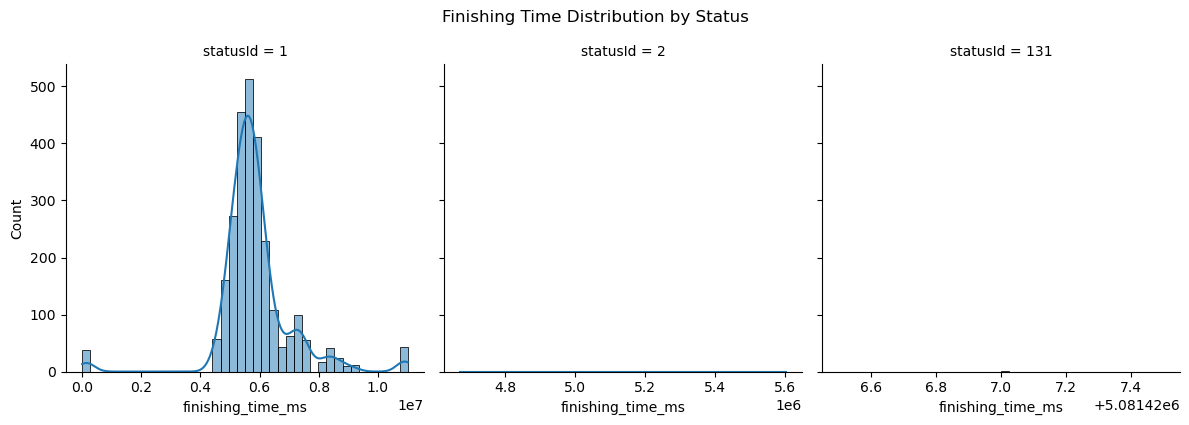

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(df, col="statusId", col_wrap=3, height=4, sharex=False)
g.map(sns.histplot, "finishing_time_ms", bins=40, kde=True)

g.fig.suptitle("Finishing Time Distribution by Status", y=1.05)
plt.show()


In [20]:
# Step 1: Filter only completed race results (statusId = 1) for regression
df = df[df['statusId'] == 1].copy()

print("After filtering (only statusId=1 kept):", df.shape)


After filtering (only statusId=1 kept): (2647, 31)


In [21]:
# Step 2: Remove unrealistic extremely low or high finishing times

# Lower bound (~30 mins in ms = 1.8M ms) safety cutoff
lower_bound = 1.8e6  

# Upper bound (~2 hours = 7.2M ms)
upper_bound = 8.5e6  

df = df[(df['finishing_time_ms'] > lower_bound) &
                    (df['finishing_time_ms'] < upper_bound)].copy()

print("After time-based filtering:", df.shape)


After time-based filtering: (2521, 31)


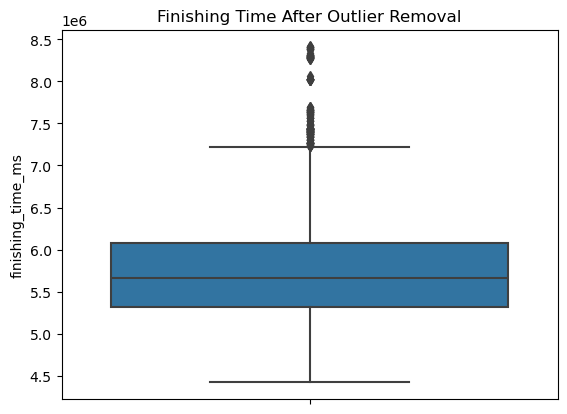

In [23]:
sns.boxplot(y=df['finishing_time_ms'])
plt.title("Finishing Time After Outlier Removal")
plt.show()


### Independent Variable Correlation

##### 1. Target Variable — Finishing Time Distribution

c:\Users\raksh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


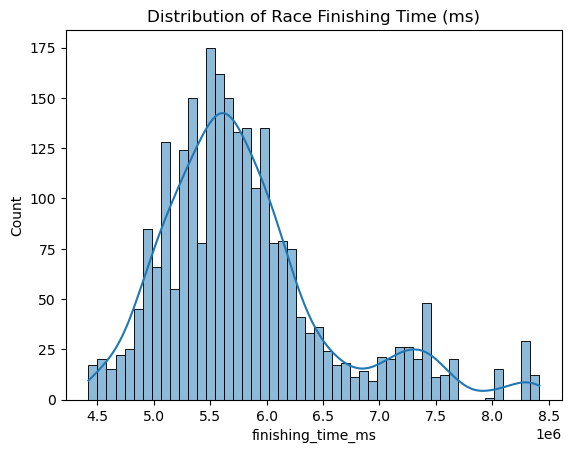

count    2.521000e+03
mean     5.808398e+06
std      7.554587e+05
min      4.421143e+06
25%      5.312471e+06
50%      5.667703e+06
75%      6.078774e+06
max      8.417096e+06
Name: finishing_time_ms, dtype: float64


In [25]:
sns.histplot(df.finishing_time_ms, bins=50, kde=True)
plt.title("Distribution of Race Finishing Time (ms)")
plt.show()

print(df.finishing_time_ms.describe())


##### 2. Track Length / Distance vs Finishing Time

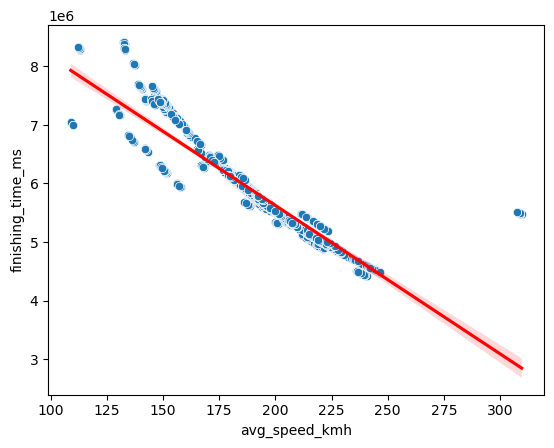

In [29]:
df['avg_speed_kmh'] = (df['total_distance_km'] / (df['finishing_time_ms'] / 3.6e6))
df['pace_ms_per_km'] = df['finishing_time_ms'] / df['total_distance_km']
sns.scatterplot(data=df, x="avg_speed_kmh", y="finishing_time_ms")
sns.regplot(data=df, x="avg_speed_kmh", y="finishing_time_ms", scatter=False, color="red")
plt.show()


##### 3.Constructor Comparison

c:\Users\raksh\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


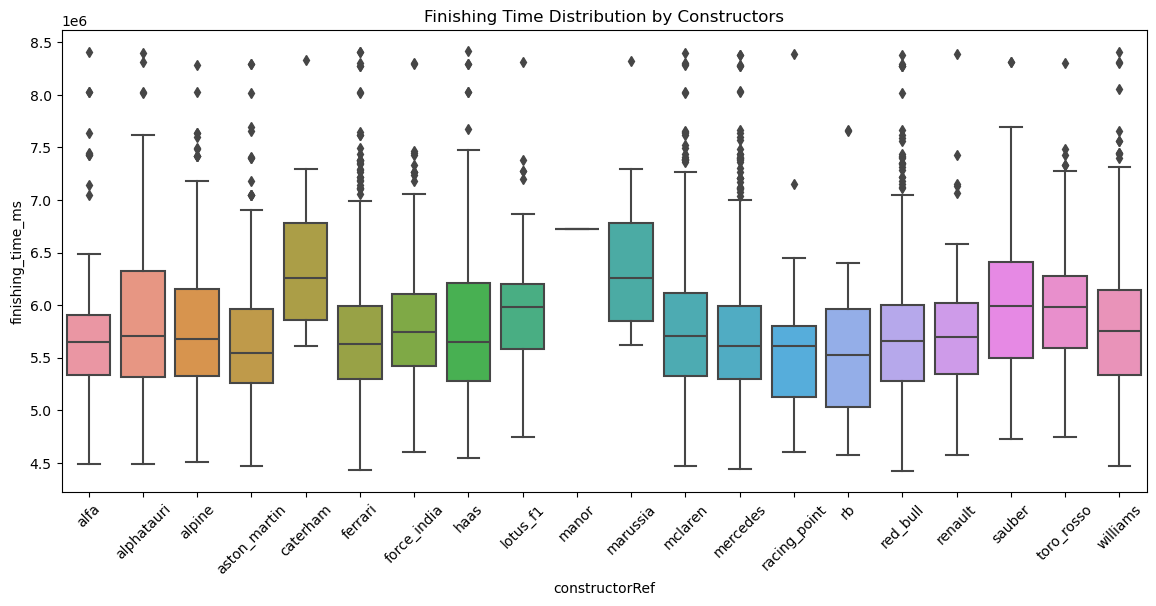

In [30]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x="constructorRef", y="finishing_time_ms")
plt.xticks(rotation=45)
plt.title("Finishing Time Distribution by Constructors")
plt.show()


##### 4.Driver Form (Last 10 Races) vs Finishing Time

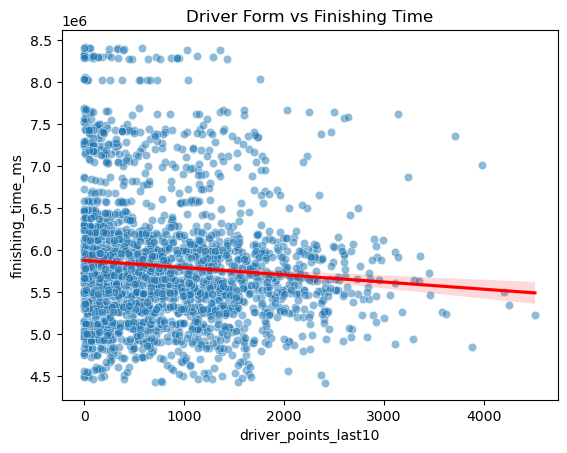

In [31]:
sns.scatterplot(data=df, x="driver_points_last10", y="finishing_time_ms", alpha=0.5)
sns.regplot(data=df, x="driver_points_last10", y="finishing_time_ms", scatter=False, color="red")
plt.title("Driver Form vs Finishing Time")
plt.show()


### Feature Engineering 

##### 1. Circuit historical finishing time mean (past performance only)

In [32]:
circuit_mean_time = (
    df.groupby("circuitId")["finishing_time_ms"]
      .mean()
      .rename("circuit_mean_finishing_ms")
)
df = df.merge(circuit_mean_time, on="circuitId", how="left")


##### 2. Historical speed score per circuit (proxy for track characteristic)

In [33]:
df["circuit_speed_index"] = df["lap_length_km"] / df["circuit_mean_finishing_ms"]


##### 3. Pit Stop Intensity for track (historically)

In [37]:
pit_intensity = (
    df.groupby("circuitId")["stops_count"]
      .mean()
      .rename("avg_pit_intensity_track")
)
df = df.merge(pit_intensity, on="circuitId", how="left")



##### 4. Track Safety Profile (chaos factor)

In [ ]:
# dnf_rate = (
#     results.groupby("circuitId")["positionOrder"]
#            .apply(lambda x: (x==0).mean())
#            .rename("circuit_dnf_rate")
# )


NameError: name 'results' is not defined

### MULTI-COLLINEARITY

In [64]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Select only numeric features (exclude target manually)
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Drop highly sparse dummy columns or convert infinities
X_vif = X[numeric_features].replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.dropna(axis=0)   # drop rows with missing values for VIF only

def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df.values, i)
        for i in range(df.shape[1])
    ]
    return vif_data.sort_values(by="VIF", ascending=False)

vif_df = calculate_vif(X_vif)

print("\n===== Variance Inflation Factor (VIF) =====")
display(vif_df.head(25))   # show top 25 highest VIF



===== Variance Inflation Factor (VIF) =====


,Feature,VIF
9,lap_length_km,9004.499893
12,circuit_speed_index,2784.443227
11,circuit_mean_finishing_ms,2129.925374
10,total_distance_km,2059.016317
1,laps,1871.683535
6,constructor_points,36.464193
5,driver_standing_points,29.485975
13,avg_pit_intensity_track,27.750966
8,constructor_points_last10,18.546176
7,driver_points_last10,13.276496


In [ ]:
categorical_features = ['circuitRef', 'driverRef','constructorRef']  # <-- choose which categorical vars to encode
numerical_features = [
    'grid','laps','stops_count','total_pit_ms','avg_pit_ms',
    'driver_standing_points','constructor_points',
    'driver_points_last10','constructor_points_last10',
    'lap_length_km','total_distance_km',
    'circuit_mean_finishing_ms','circuit_speed_index','avg_pit_intensity_track'
]

### MODEL BUILDING

In [71]:
# Linear Regression Model 

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



categorical_features = ['circuitRef', 'driverRef','constructorRef']  # <-- choose which categorical vars to encode
numerical_features = [
    'grid','total_pit_ms',
     'driver_points_last10','constructor_points_last10',
    'lap_length_km','avg_pit_intensity_track'
]

target = "finishing_time_ms"


# ===========================================
# 3️⃣ One-hot encode selected categorical columns
# ===========================================
df_model = pd.get_dummies(
    df[categorical_features + numerical_features + [target]],
    columns=categorical_features,
    drop_first=True
).fillna(0) # Safety fill, can refine later


# ===========================================
# 4️⃣ Split into X and y
# ===========================================
X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ===========================================
# 5️⃣ Train Model
# ===========================================
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


# ===========================================
# 6️⃣ Performance Metrics (incl. Adjusted R²)
# ===========================================
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

n, p = X_test.shape
adj_r2 = 1 - (1-r2) * ((n-1)/(n-p-1))

print("\n===== Model Performance =====")
print(f"R² Score:           {r2:.4f}")
print(f"Adjusted R² Score:  {adj_r2:.4f}")
print(f"MAE:                {mae:.2f}")
print(f"RMSE:               {rmse:.2f}")


# ===========================================
# 7️⃣ Feature Coefficients
# ===========================================
coef_df = pd.DataFrame({"Feature":X.columns,"Coefficient":model.coef_})\
            .sort_values(by="Coefficient")

print("\n===== Top Positive Coefficients (Slower Lap Effect) =====")
display(coef_df.tail(10))

print("\n===== Top Negative Coefficients (Faster Lap Effect) =====")
display(coef_df.head(10))



===== Model Performance =====
R² Score:           0.8715
Adjusted R² Score:  0.8313
MAE:                188949.68
RMSE:               268569.80

===== Top Positive Coefficients (Slower Lap Effect) =====


,Feature,Coefficient
93,driverRef_sutil,6.200124e+05
8,circuitRef_baku,6.472623e+05
110,constructorRef_marussia,6.581612e+05
15,circuitRef_istanbul,6.695818e+05
20,circuitRef_monaco,6.731168e+05
85,driverRef_rosberg,6.910361e+05
6,circuitRef_americas,6.934415e+05
37,circuitRef_yeongam,7.504584e+05
50,driverRef_garde,8.177274e+05
18,circuitRef_marina_bay,1.561662e+06



===== Top Negative Coefficients (Faster Lap Effect) =====


,Feature,Coefficient
22,circuitRef_mugello,-491646.135497
25,circuitRef_red_bull_ring,-437019.407763
21,circuitRef_monza,-424019.837183
4,lap_length_km,-286387.639908
17,circuitRef_losail,-89102.952834
112,constructorRef_mercedes,-61905.550599
14,circuitRef_interlagos,-58563.747289
38,circuitRef_zandvoort,-33157.614525
103,constructorRef_aston_martin,-25362.985962
30,circuitRef_silverstone,-18615.829670


In [66]:
# ===========================================================
#  Ridge & Lasso Regression for Regularization
# ===========================================================

from sklearn.linear_model import Ridge, Lasso

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)

    n, p = X_test.shape
    adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

    print(f"\n===== {model_name} Performance =====")
    print(f"R²:          {r2:.4f}")
    print(f"Adjusted R²: {adj_r2:.4f}")
    print(f"MAE:         {mae:.2f}")
    print(f"RMSE:        {rmse:.2f}")
    return r2, adj_r2, mae, rmse


# Train & Compare Models
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.001, max_iter=5000)   # adjust later based on results

evaluate_model(model, X_train, y_train, X_test, y_test, "Linear Regression")   # base model
evaluate_model(ridge_model, X_train, y_train, X_test, y_test, "Ridge Regression")
evaluate_model(lasso_model, X_train, y_train, X_test, y_test, "Lasso Regression")



===== Linear Regression Performance =====
R²:          0.8758
Adjusted R²: 0.8362
MAE:         181694.79
RMSE:        263961.51

===== Ridge Regression Performance =====
R²:          0.8773
Adjusted R²: 0.8382
MAE:         179664.57
RMSE:        262356.89

===== Lasso Regression Performance =====
R²:          0.8758
Adjusted R²: 0.8362
MAE:         181694.39
RMSE:        263961.38


c:\Users\raksh\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.941e+13, tolerance: 1.155e+11
  model = cd_fast.enet_coordinate_descent(


(0.875837203054882, 0.8361831160724098, 181694.38936849937, 263961.3813619068)

#### Final Plots

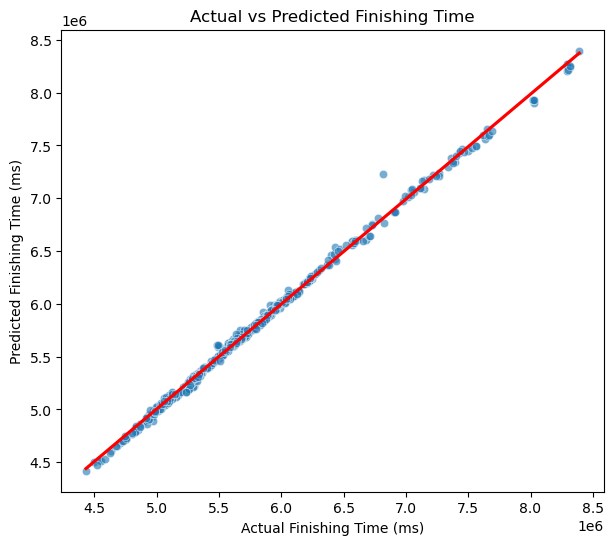

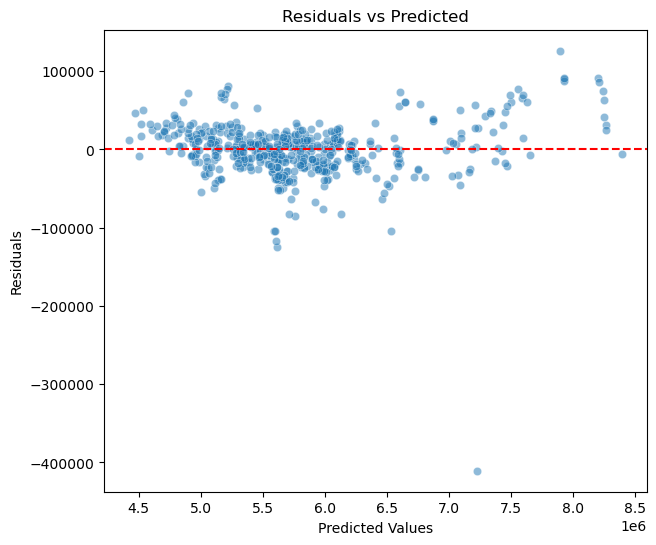

c:\Users\raksh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


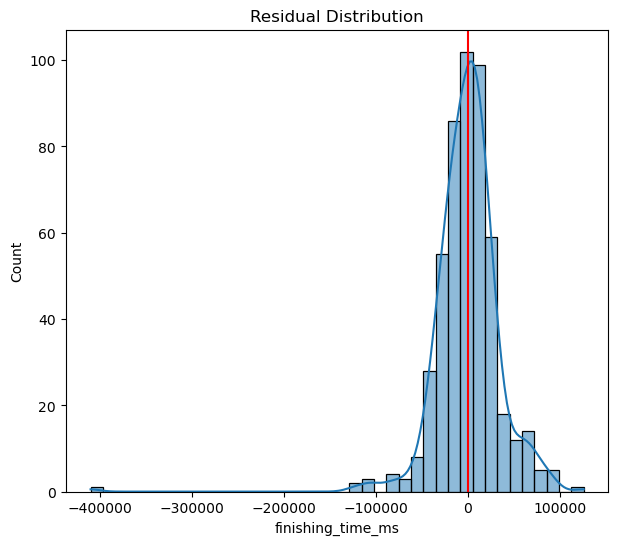

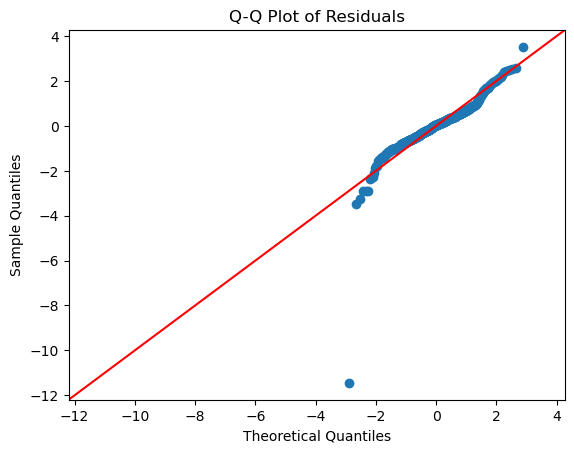

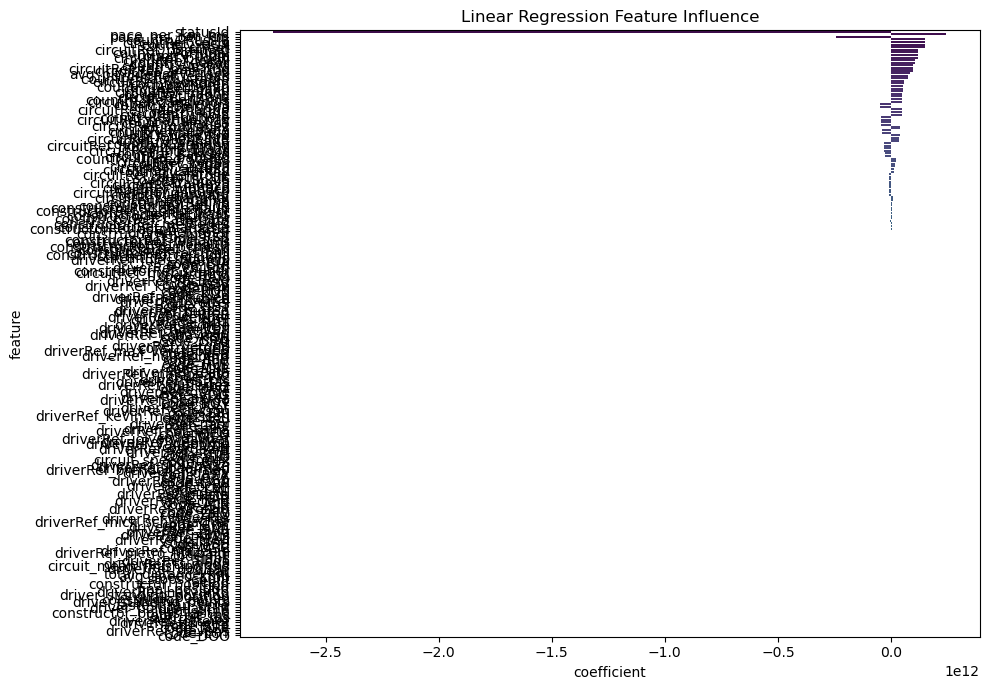


===== Final Linear Regression Report =====
R² Score:        0.9977
Adjusted R²:     0.9957
MAE:             23,376.02
RMSE:            35,859.60


In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm

# ==== Assuming you have already trained ====
# X_train_f, X_test_f, y_train_f, y_test_f
# lr2 = LinearRegression(); lr2.fit(X_train_f, y_train_f)
# y_pred_f = lr2.predict(X_test_f)

# ----------------- 1. Actual vs Predicted -----------------
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test_f, y=y_pred_f, alpha=0.6)
sns.regplot(x=y_test_f, y=y_pred_f, scatter=False, color="red")
plt.xlabel("Actual Finishing Time (ms)")
plt.ylabel("Predicted Finishing Time (ms)")
plt.title("Actual vs Predicted Finishing Time")
plt.show()

# ----------------- 2. Residuals vs Fitted -----------------
residuals = y_test_f - y_pred_f

plt.figure(figsize=(7,6))
sns.scatterplot(x=y_pred_f, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# ----------------- 3. Residual Distribution -----------------
plt.figure(figsize=(7,6))
sns.histplot(residuals, bins=40, kde=True)
plt.axvline(0, color='red')
plt.title("Residual Distribution")
plt.show()

# ----------------- 4. Q-Q Plot -----------------
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

# ----------------- 5. Feature Coefficient Importance -----------------
coef_df = pd.DataFrame({
    'feature': X_train_f.columns,
    'coefficient': lr2.coef_
}).sort_values(by="coefficient", key=abs, ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(data=coef_df, y='feature', x='coefficient', palette="viridis")
plt.title("Linear Regression Feature Influence")
plt.tight_layout()
plt.show()

# ----------------- 6. Summary Metrics Print -----------------
print("\n===== Final Linear Regression Report =====")
print(f"R² Score:        {r2_score(y_test_f, y_pred_f):.4f}")
print(f"Adjusted R²:     {1 - (1-r2_score(y_test_f,y_pred_f))*(len(y_test_f)-1)/(len(y_test_f)-X_test_f.shape[1]-1):.4f}")
print(f"MAE:             {mean_absolute_error(y_test_f, y_pred_f):,.2f}")
print(f"RMSE:            {np.sqrt(mean_squared_error(y_test_f, y_pred_f)):,.2f}")
